In [7]:
# ============================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import time
import os
from google.colab import files
import zipfile
from tensorflow.keras import regularizers

2026-02-27 15:35:58.953243: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-27 15:35:59.144762: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-27 15:36:10.627645: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ============================
# 1. RUTAS
# ============================

base_dir = "../data/selected"   # ajusta si es necesario

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

# ============================
# 2. PARÁMETROS
# ============================

img_size = (128, 128)
batch_size = 128
val_split = 0.2   # 20% del train será validación

# ============================
# 3. GENERADORES
# ============================

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=val_split
)

test_datagen = ImageDataGenerator(rescale=1./255)

# ============================
# 4. DATASETS
# ============================

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Clases detectadas:", train_data.class_indices)
print("Número de clases:", train_data.num_classes)

Found 3914 images belonging to 10 classes.
Found 975 images belonging to 10 classes.
Found 1638 images belonging to 10 classes.
Clases detectadas: {'Apple Golden 1': 0, 'Apple Red 1': 1, 'Banana 1': 2, 'Grape White 1': 3, 'Lemon 1': 4, 'Mango 1': 5, 'Orange 1': 6, 'Peach 1': 7, 'Pear 1': 8, 'Strawberry 1': 9}
Número de clases: 10


In [3]:
from tensorflow.keras import layers, models, regularizers

num_classes = 10

model = models.Sequential([

    #capa 1
    layers.Conv2D(128, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    #capa 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    #capa 3
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    #TRANSICIÓN A DENSAS
    layers.Flatten(),

    #layers.Dense(128, activation='relu',
     #            kernel_regularizer=regularizers.l2(0.001)),

    layers.Dropout(0.4),

    # capa de SALIDA
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

/home/kali/proyectos/Clasificaciondefrutas.udea.novateam/venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-27 15:36:21.967540: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │       250,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,306,826 (12.61 MB)

 Trainable params: 3,306,378 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [5]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)

Epoch 1/15


C:\Users\ADMH2\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


123/123 ━━━━━━━━━━━━━━━━━━━━ 167s 1s/step - accuracy: 0.7976 - loss: 1.7951 - val_accuracy: 0.1005 - val_loss: 53.4292
Epoch 2/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.9752 - loss: 0.4431 - val_accuracy: 0.1877 - val_loss: 32.4734
Epoch 3/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.9851 - loss: 0.3995 - val_accuracy: 0.5990 - val_loss: 8.7291
Epoch 4/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9879 - loss: 0.3839 - val_accuracy: 0.9128 - val_loss: 1.0969
Epoch 5/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 133s 1s/step - accuracy: 0.9829 - loss: 0.4635 - val_accuracy: 0.9744 - val_loss: 0.5474
Epoch 6/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9803 - loss: 0.5217 - val_accuracy: 0.8297 - val_loss: 1.9260
Epoch 7/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.9829 - loss: 0.5774 - val_accuracy: 0.9938 - val_loss: 0.4519
Epoch 8/15
123/123 ━━━━━━━━━━━━━━━━━━━━ 130s 1s/step - accuracy: 0.9955 - loss: 0.4517 - val_accuracy: 0.9

C:\Users\ADMH2\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


52/52 ━━━━━━━━━━━━━━━━━━━━ 15s 245ms/step - accuracy: 0.9696 - loss: 0.4319

Precisión en prueba: 0.9847
52/52 ━━━━━━━━━━━━━━━━━━━━ 11s 195ms/step

Reporte de clasificación:
                precision    recall  f1-score   support

Apple Golden 1       1.00      0.89      0.94       160
   Apple Red 1       1.00      0.98      0.99       164
      Banana 1       1.00      1.00      1.00       166
 Grape White 1       1.00      1.00      1.00       166
       Lemon 1       0.91      1.00      0.95       164
       Mango 1       1.00      1.00      1.00       166
      Orange 1       0.98      1.00      0.99       160
       Peach 1       0.98      0.98      0.98       164
        Pear 1       1.00      1.00      1.00       164
  Strawberry 1       1.00      1.00      1.00       164

      accuracy                           0.98      1638
     macro avg       0.99      0.98      0.98      1638
  weighted avg       0.99      0.98      0.98      1638



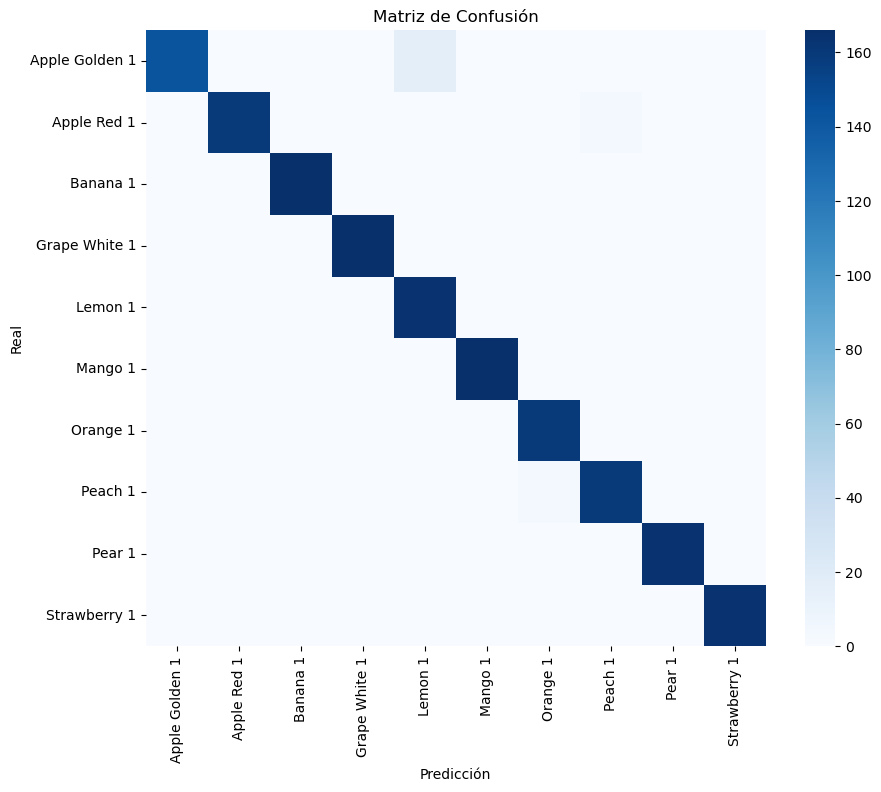

In [8]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluación básica
test_loss, test_acc = model.evaluate(test_data)
print(f"\nPrecisión en prueba: {test_acc:.4f}")
print(f"\nPerdida en prueba: {test_loss:.4f}")

# Predicciones
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes
class_labels = list(test_data.class_indices.keys())

# Reporte
print("\nReporte de clasificación:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues",
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

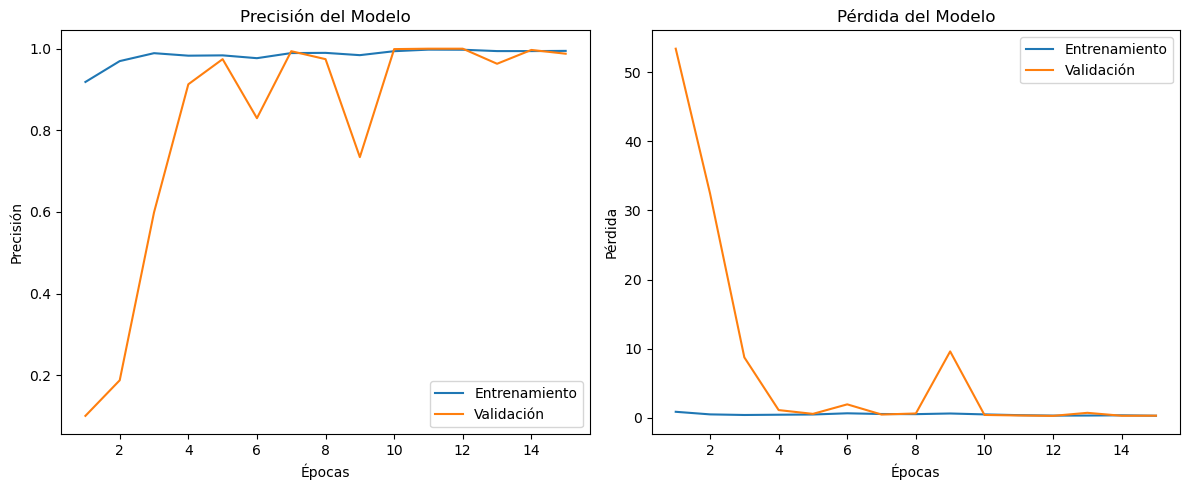


Diagnóstico del modelo:
Overfitting: el modelo aprende demasiado el entrenamiento y no generaliza bien.


In [9]:
import matplotlib.pyplot as plt

# ============================
# 6. VISUALIZACIÓN DE MÉTRICAS
# ============================

# Extraer métricas del entrenamiento
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(12, 5))

# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc, label='Entrenamiento')
plt.plot(epochs, val_acc, label='Validación')
plt.title('Precisión del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss, label='Entrenamiento')
plt.plot(epochs, val_loss, label='Validación')
plt.title('Pérdida del Modelo')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.tight_layout()
plt.show()


# ============================
# Diagnóstico automático
# ============================

train_acc_final = train_acc[-1]
val_acc_final = val_acc[-1]
train_loss_final = train_loss[-1]
val_loss_final = val_loss[-1]

print("\nDiagnóstico del modelo:")

if train_acc_final < 0.70:
    print("Posible Underfitting: el modelo no está aprendiendo lo suficiente.")
elif val_loss_final > train_loss_final * 1.3:
    print("Overfitting: el modelo aprende demasiado el entrenamiento y no generaliza bien.")
else:
    print("Buen ajuste: el modelo generaliza correctamente.")